**Dataset Overview**

The Glass Identification Dataset is a multiclass classification dataset used to classify glass types based on chemical composition.

**Mount Drive (Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [2]:
import pandas as pd

glass_data = pd.read_csv('drive/MyDrive/Datasets For ML/Glass Classification Dataset.csv')

print("Shape:", glass_data.shape)
print("Duplicated:", glass_data.duplicated().sum())
print("Null Values:\n", glass_data.isnull().sum())
print("\nFirst 2 Rows:\n", glass_data.head(2))

Shape: (214, 10)
Duplicated: 1
Null Values:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

First 2 Rows:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1


**Remove Duplicates**

In [3]:
glass_data = glass_data.drop_duplicates()
glass_data.shape

(213, 10)

**Feature–Label Separation**

In [4]:
X, Y = glass_data.iloc[:, :-1], glass_data.iloc[:, -1]

**Train–Test Split**

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (170, 9)
X_test Shape: (43, 9)


**Hyperparameter Tuning using OOB Score**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [100, 200]
max_depth_list = [None, 10, 20]
max_features_list = [None, 'sqrt', 'log2']
min_samples_split_list = [2, 5]
min_samples_leaf_list = [1, 2, 4]
max_leaf_nodes_list = [None, 10, 20, 50, 100]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        for features in max_features_list:
            for min_split in min_samples_split_list:
               for min_leaf in min_samples_leaf_list:
                 for max_leaf in max_leaf_nodes_list:

                    model = RandomForestClassifier(
                        n_estimators=n,
                        max_depth=depth,
                        max_features=features,
                        min_samples_split=min_split,
                        min_samples_leaf=min_leaf,
                        max_leaf_nodes=max_leaf,
                        bootstrap=True,
                        oob_score=True,
                        random_state=42,
                        n_jobs=-1
                    )

                    model.fit(X_train, Y_train)

                    results.append([
                        n, depth, features, min_split, min_leaf, max_leaf, model.oob_score_
                    ])

results_df = pd.DataFrame(results, columns=[
    "n_estimators",
    "max_depth",
    "max_features",
    "min_samples_split",
    "min_samples_leaf",
    "max_leaf_nodes",
    "OOB_Score"
])

results_df.sort_values(by="OOB_Score", ascending=False).head()

,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf,max_leaf_nodes,OOB_Score
300,200,NaN,sqrt,2,1,NaN,0.794118
330,200,NaN,log2,2,1,NaN,0.794118
480,200,20.0,sqrt,2,1,NaN,0.794118
510,200,20.0,log2,2,1,NaN,0.794118
63,100,NaN,log2,2,1,50.0,0.782353


**Train Final Model**

In [ ]:
best_params = results_df.sort_values(
    by="OOB_Score", ascending=False
).iloc[0]

max_depth_val = best_params['max_depth']
max_depth_for_model = None if pd.isna(max_depth_val) else int(max_depth_val)

# Handle max_leaf_nodes: Convert NaN to None
max_leaf_nodes_val = best_params['max_leaf_nodes']
max_leaf_nodes_for_model = None if pd.isna(max_leaf_nodes_val) else int(max_leaf_nodes_val)

best_model = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=max_depth_for_model,
    max_features=best_params['max_features'],
    min_samples_split=int(best_params['min_samples_split']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    max_leaf_nodes=max_leaf_nodes_for_model,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)

**Bias–Variance Insight**

In [ ]:
train_accuracy = best_model.score(X_train, Y_train)
test_accuracy = best_model.score(X_test, Y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.813953488372093


**Interpretation:**

If Train >> Test → Overfitting

If Train ≈ Test → Good Generalization

If both low → Underfitting

**OOB Error Calculation**

In [ ]:
print("OOB Score:", best_model.oob_score_)

oob_error = 1 - best_model.oob_score_
print("OOB Error:", oob_error)

OOB Score: 0.7941176470588235
OOB Error: 0.20588235294117652


OOB Error = Internal validation error (without separate validation set).

**Feature Importance Plot**

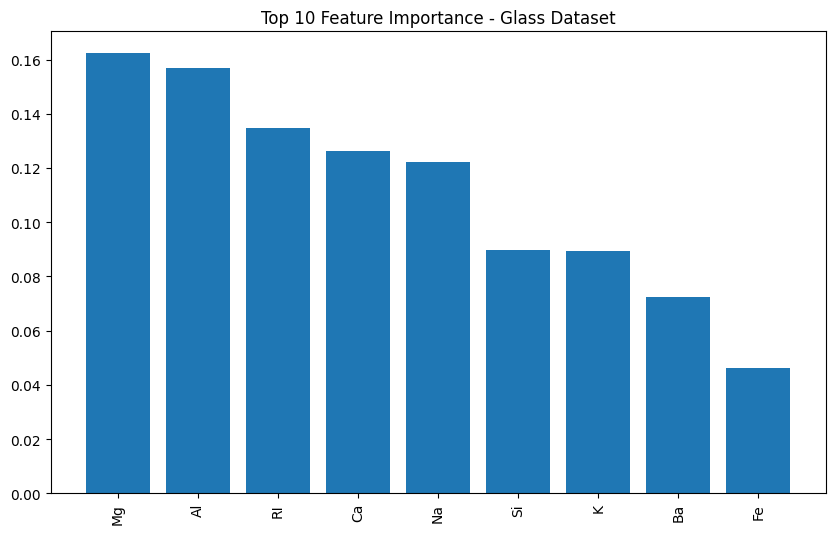

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Get the number of features available (which is 9)
num_features_to_plot = len(importances)

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importance - Glass Dataset")
# Adjust the range and slice to match the actual number of features
plt.bar(range(num_features_to_plot), importances[indices])
plt.xticks(range(num_features_to_plot), X.columns[indices], rotation=90)
plt.show()

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.813953488372093

Confusion Matrix:
 [[13  1  0  0  0  0]
 [ 3 10  0  1  1  0]
 [ 1  0  2  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.83      0.67      0.74        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.81        43
   macro avg       0.82      0.82      0.81        43
weighted avg       0.83      0.81      0.81        43

